In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.plotting as plot
import pandapower.plotting.geo as pgeo
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt

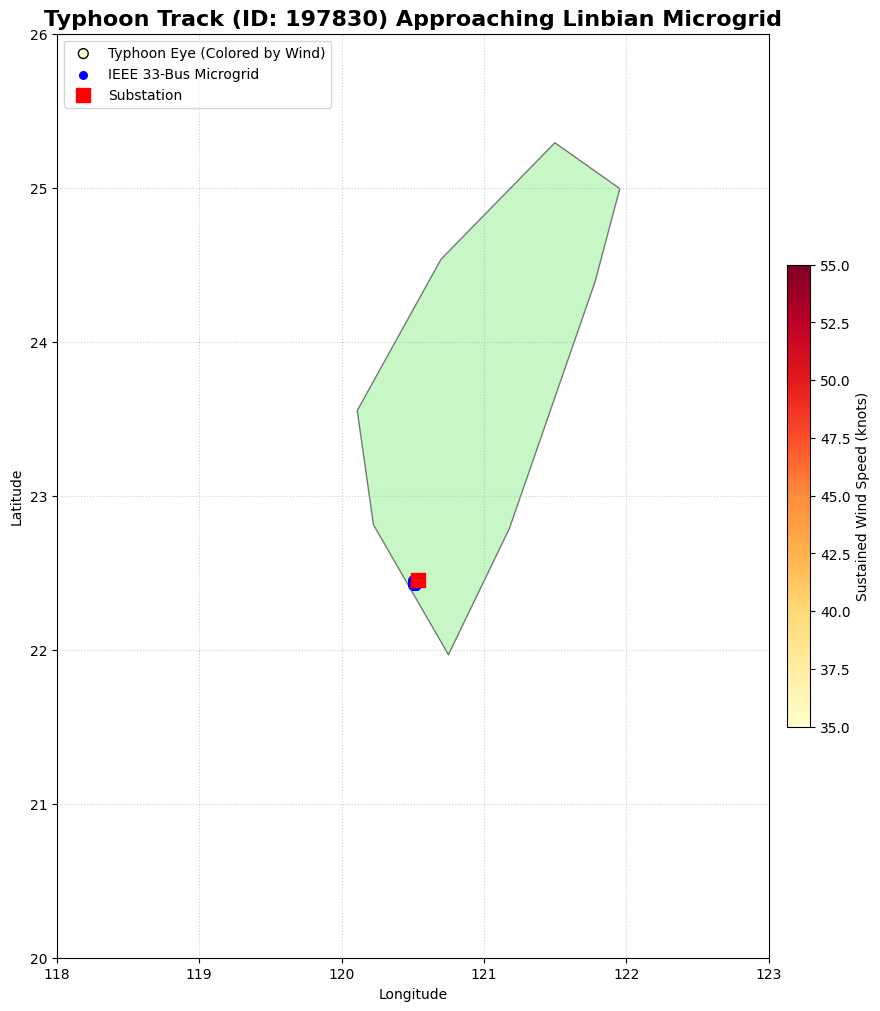

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import networkx as nx
import pandapower.networks as pn

# ==============================================================================
# 1. REBUILD THE MICROGRID GEODATA (From our previous step)
# ==============================================================================
net = pn.case33bw()
net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)

G = nx.Graph()
G.add_edges_from(net.line[['from_bus', 'to_bus']].values)
pos = nx.kamada_kawai_layout(G)

for bus_id, coords in pos.items():
    net.bus_geodata.loc[bus_id, 'x'] = coords[0]
    net.bus_geodata.loc[bus_id, 'y'] = coords[1]

# Linbian, Taiwan
base_lat, base_lng = 22.434, 120.516
x_min, x_max = net.bus_geodata.x.min(), net.bus_geodata.x.max()
y_min, y_max = net.bus_geodata.y.min(), net.bus_geodata.y.max()
x_range, y_range = x_max - x_min, y_max - y_min

# Scale to ~5km footprint
net.bus_geodata.x = base_lng + ((net.bus_geodata.x - x_min) / x_range - 0.5) * 0.045
net.bus_geodata.y = base_lat + ((net.bus_geodata.y - y_min) / y_range - 0.5) * 0.045

# Create a GeoDataFrame for the Microgrid Buses
geometry_buses = [Point(xy) for xy in zip(net.bus_geodata.x, net.bus_geodata.y)]
gdf_microgrid = gpd.GeoDataFrame(net.bus_geodata, geometry=geometry_buses, crs="EPSG:4326")

# ==============================================================================
# 2. LOAD AND PREPARE THE TYPHOON DATA
# ==============================================================================
# Load your JMA dataset
df_typhoon = pd.read_csv('raw/typhoon_data.csv')

# SELECT A SPECIFIC TYPHOON
# Let's pick a specific seq_id. (You will want to change this to a highly destructive 
# storm that hit Southern Taiwan, like Morakot or Koinu, once you find its ID).
# For now, I'll grab the very first ID in your dataset just to make the code run.
target_seq_id = df_typhoon['seq_id'].unique()[0] 
storm_data = df_typhoon[df_typhoon['seq_id'] == target_seq_id].copy()

# Filter out points where wind is 0 (often genesis/dissipation stages) to clean the plot
storm_data = storm_data[storm_data['wind'] > 0]

# Create a GeoDataFrame for the Typhoon Track
geometry_storm = [Point(xy) for xy in zip(storm_data.lng, storm_data.lat)]
gdf_storm = gpd.GeoDataFrame(storm_data, geometry=geometry_storm, crs="EPSG:4326")

# Create a LineString to draw the continuous path of the storm
storm_path = LineString(gdf_storm.geometry.tolist())
gdf_path = gpd.GeoDataFrame([1], geometry=[storm_path], crs="EPSG:4326")

# ==============================================================================
# 3. GEOGRAPHICAL PLOTTING (TAIWAN CONTEXT)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 12))

# A. Draw the Base Map of Taiwan
# GeoPandas 1.0+ Fix: Read the country shapes directly from the Natural Earth server
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Standardize column names to lowercase just in case the server format changes
world.columns = world.columns.str.lower()

# Filter for Taiwan and plot it
taiwan = world[world['name'] == "Taiwan"]
taiwan.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

# B. Draw the Typhoon Path
# Plot the continuous line
gdf_path.plot(ax=ax, color='gray', linewidth=2, linestyle='--', zorder=1)
# Plot the individual hourly data points, colored by wind intensity!
scatter = ax.scatter(gdf_storm.geometry.x, gdf_storm.geometry.y, 
                     c=gdf_storm['wind'], cmap='YlOrRd', s=50, 
                     edgecolor='black', zorder=2, label='Typhoon Eye (Colored by Wind)')

# C. Draw the Microgrid
gdf_microgrid.plot(ax=ax, color='blue', markersize=30, zorder=3, label='IEEE 33-Bus Microgrid')
# Highlight the main substation (Bus 0)
ax.scatter(net.bus_geodata.loc[0, 'x'], net.bus_geodata.loc[0, 'y'], 
           color='red', marker='s', s=100, zorder=4, label='Substation')

# ==============================================================================
# 4. FORMATTING AND DISPLAY
# ==============================================================================
# Add a colorbar for the typhoon wind speeds
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Sustained Wind Speed (knots)')

# Zoom the map slightly so we aren't looking at the whole ocean
# Focus roughly on Taiwan and the approaching storm
ax.set_xlim(118.0, 123.0)
ax.set_ylim(20.0, 26.0)

ax.set_title(f"Typhoon Track (ID: {target_seq_id}) Approaching Linbian Microgrid", fontsize=16, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.show()

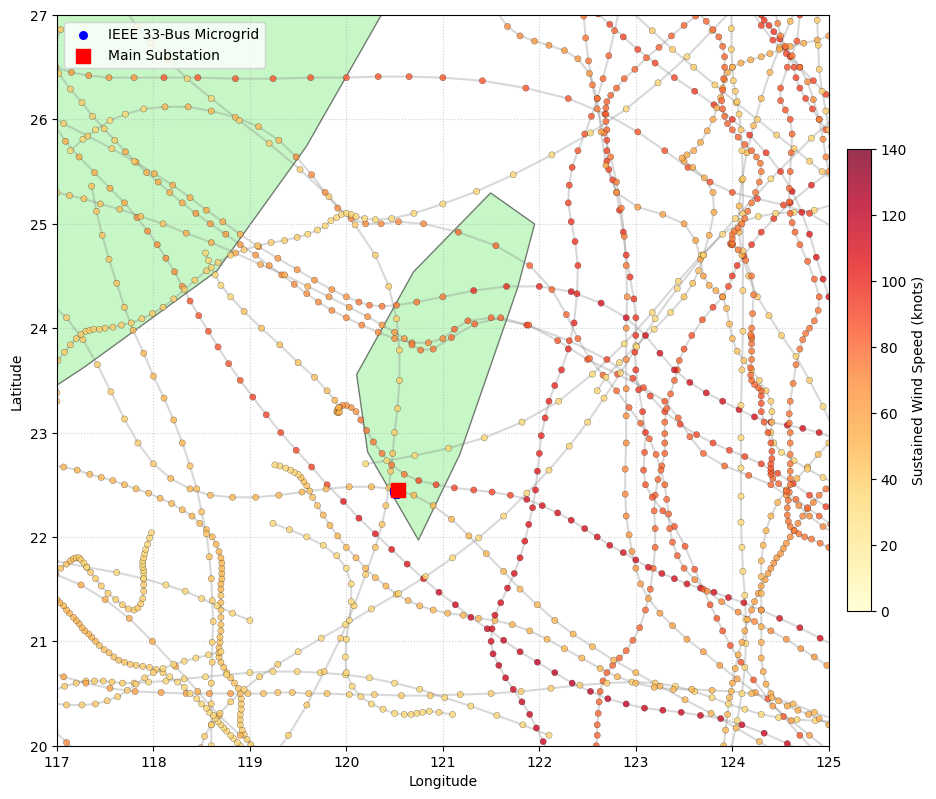

In [3]:
# ==============================================================================
# 2. LOAD AND PREPARE THE TYPHOON DATA (LAST 30)
# ==============================================================================
# Load your JMA dataset
df_typhoon = pd.read_csv('raw/typhoon_data.csv')

# Get the last 30 unique typhoon IDs
last_30_ids = df_typhoon['seq_id'].unique()[-200:]

# ==============================================================================
# 3. GEOGRAPHICAL PLOTTING (TAIWAN REGION)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10))

# A. Draw the Base Map
# We fetch the countries directly from Natural Earth
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.columns = world.columns.str.lower()
# Plot only Asia to save rendering memory
asia = world[world['continent'] == 'Asia']
asia.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

# B. Plot the Last 30 Typhoon Tracks
# We loop through the IDs to draw them as distinct tracks
for seq in last_30_ids:
    # Filter for the specific storm and remove genesis/dissipation (0 wind) stages
    track = df_typhoon[(df_typhoon['seq_id'] == seq) & (df_typhoon['wind'] > 0)].copy()
    
    if len(track) > 1:
        # Draw the continuous path line (slightly transparent gray)
        ax.plot(track['lng'], track['lat'], color='gray', linewidth=1.5, alpha=0.3, zorder=1)
        
        # Overlay the individual data points colored by wind intensity
        # We set vmin/vmax so the color scale is consistent across all 30 storms
        scatter = ax.scatter(track['lng'], track['lat'], c=track['wind'], cmap='YlOrRd', 
                             s=20, edgecolor='black', linewidth=0.2, alpha=0.8, zorder=2,
                             vmin=df_typhoon['wind'].min(), vmax=df_typhoon['wind'].max())

# C. Draw the Microgrid
gdf_microgrid.plot(ax=ax, color='blue', markersize=30, zorder=3, label='IEEE 33-Bus Microgrid')
ax.scatter(net.bus_geodata.loc[0, 'x'], net.bus_geodata.loc[0, 'y'], 
           color='red', marker='s', s=100, zorder=4, label='Main Substation')

# ==============================================================================
# 4. FORMATTING, CROP, AND DISPLAY
# ==============================================================================
# Add a colorbar for the typhoon wind speeds
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Sustained Wind Speed (knots)')

# ---> THE CROP (Zooming in on Taiwan) <---
# This forces matplotlib to ignore the rest of Asia and frame Taiwan perfectly
ax.set_xlim(117.0, 125.0)  # Longitude bounds
ax.set_ylim(20.0, 27.0)    # Latitude bounds

# ax.set_title("Historical Tracks of the Last 30 Typhoons Approaching Taiwan", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.show()

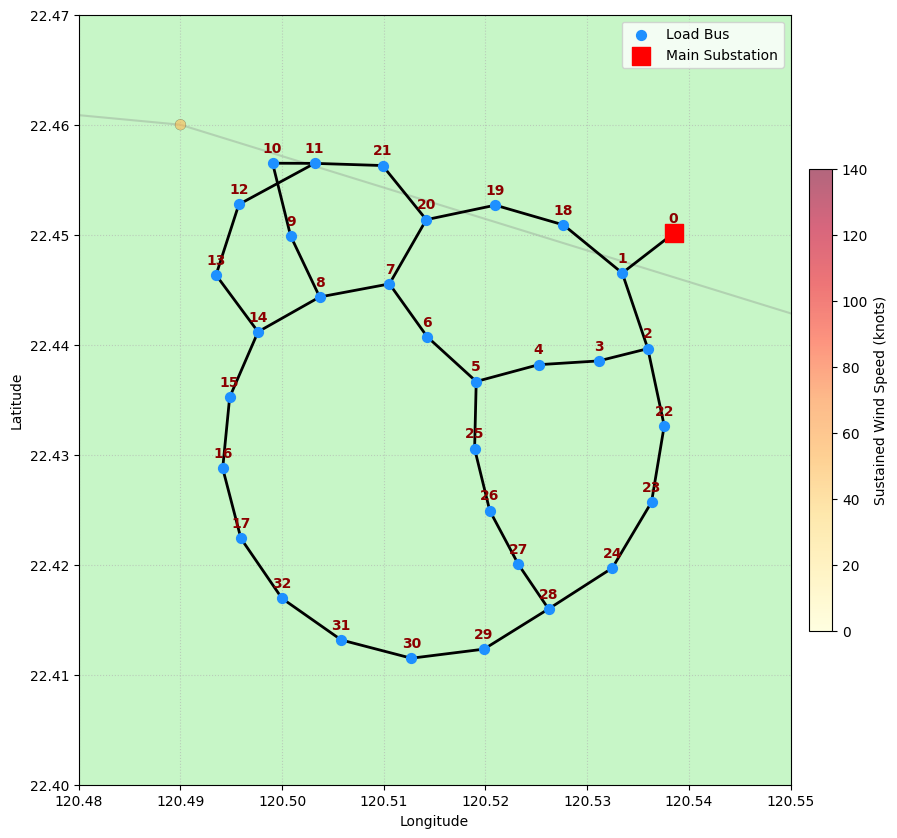

In [6]:
# ==============================================================================
# 3. GEOGRAPHICAL PLOTTING (PINGTUNG DRILL-DOWN)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10))

# A. Draw the Base Map (Taiwan coastline)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.columns = world.columns.str.lower()
asia = world[world['continent'] == 'Asia']
asia.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

# B. Plot the Last 30 Typhoon Tracks
for seq in last_30_ids:
    track = df_typhoon[(df_typhoon['seq_id'] == seq) & (df_typhoon['wind'] > 0)].copy()
    if len(track) > 1:
        ax.plot(track['lng'], track['lat'], color='gray', linewidth=1.5, alpha=0.3, zorder=1)
        scatter = ax.scatter(track['lng'], track['lat'], c=track['wind'], cmap='YlOrRd', 
                             s=60, edgecolor='black', linewidth=0.2, alpha=0.6, zorder=2,
                             vmin=df_typhoon['wind'].min(), vmax=df_typhoon['wind'].max())

# C. Draw the Microgrid (Points, Lines, and Numbers)
# Draw the lines
for idx, line in net.line.iterrows():
    fb, tb = line['from_bus'], line['to_bus']
    if fb in net.bus_geodata.index and tb in net.bus_geodata.index:
        fx, fy = net.bus_geodata.loc[fb, ['x', 'y']]
        tx, ty = net.bus_geodata.loc[tb, ['x', 'y']]
        ax.plot([fx, tx], [fy, ty], color='black', linewidth=2.0, zorder=3)

# Draw the load buses
gdf_microgrid.plot(ax=ax, color='dodgerblue', markersize=50, zorder=4, label='Load Bus')

# Draw the Substation
ax.scatter(net.bus_geodata.loc[0, 'x'], net.bus_geodata.loc[0, 'y'], 
           color='red', marker='s', s=150, zorder=5, label='Main Substation')

# Add the Bus Numbers
for bus_id in net.bus_geodata.index:
    x = net.bus_geodata.loc[bus_id, 'x']
    y = net.bus_geodata.loc[bus_id, 'y']
    ax.text(x, y + 0.001, str(bus_id), color='darkred', fontsize=10, fontweight='bold', ha='center', zorder=6)

# ==============================================================================
# 4. FORMATTING, CROP, AND DISPLAY
# ==============================================================================
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Sustained Wind Speed (knots)')

# ---> THE PINGTUNG CROP <---
# We set the limits to a ~10km bounding box around the microgrid center
ax.set_xlim(120.48, 120.55)  
ax.set_ylim(22.40, 22.47)    

# ax.set_title("Drill-Down: IEEE 33-Bus Microgrid in Linbian & Typhoon Activity", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.show()